# U.S. Job Market Dashboard
## Data Collection & Analysis

This notebook analyzes 10 years of U.S. labor market data (2014–2024) 
sourced from the Bureau of Labor Statistics (BLS) public API.

### Indicators analyzed:
- **Unemployment Rate** — percentage of people actively looking for work
- **Nonfarm Payrolls** — total number of paid U.S. workers
- **Labor Force Participation Rate** — percentage of working-age Americans 
  either employed or actively job hunting

### Key question we're answering:
> How did COVID-19 reshape the U.S. labor market, and has it fully recovered?

## Step 1 — Load & Parse Raw BLS Data

We load the raw JSON response from the BLS API and parse each 
series into a unified DataFrame with consistent column names and date formats.

In [4]:
import json
import pandas as pd
import os

# Load raw data
with open("../data/raw/bls_raw.json", "r") as f:
    raw = json.load(f)

# Series name mapping
series_names = {
    "LNS14000000": "unemployment_rate",
    "CES0000000001": "nonfarm_payrolls",
    "LNS12300000": "labor_force_participation",
    "CIU1010000000000A": "employment_cost_index"
}

# Parse each series into a dataframe
frames = []

for series in raw["Results"]["series"]:
    sid = series["seriesID"]
    name = series_names.get(sid, sid)
    rows = []
    for item in series["data"]:
        rows.append({
            "series": name,
            "year": int(item["year"]),
            "period": item["period"],
            "value": float(item["value"])
        })
    df = pd.DataFrame(rows)
    frames.append(df)

# Combine all series
combined = pd.concat(frames, ignore_index=True)

# Filter out annual averages (period starts with 'A')
combined = combined[combined["period"].str.startswith("M")]

# Create a proper date column
combined["month"] = combined["period"].str.replace("M", "").astype(int)
combined["date"] = pd.to_datetime(combined[["year", "month"]].assign(day=1))

# Sort by series and date
combined = combined.sort_values(["series", "date"]).reset_index(drop=True)

# Save to processed
os.makedirs("../data/processed", exist_ok=True)
combined.to_csv("../data/processed/bls_cleaned.csv", index=False)

print("✅ Cleaned data saved!")
print(combined.head(10))

✅ Cleaned data saved!
                      series  year period  value  month       date
0  labor_force_participation  2014    M01   58.8      1 2014-01-01
1  labor_force_participation  2014    M02   58.7      2 2014-02-01
2  labor_force_participation  2014    M03   58.9      3 2014-03-01
3  labor_force_participation  2014    M04   58.9      4 2014-04-01
4  labor_force_participation  2014    M05   58.9      5 2014-05-01
5  labor_force_participation  2014    M06   59.0      6 2014-06-01
6  labor_force_participation  2014    M07   59.0      7 2014-07-01
7  labor_force_participation  2014    M08   59.0      8 2014-08-01
8  labor_force_participation  2014    M09   59.1      9 2014-09-01
9  labor_force_participation  2014    M10   59.3     10 2014-10-01


In [5]:
# How many rows and columns?
print("Shape:", combined.shape)

# What series do we have?
print("\nSeries available:")
print(combined["series"].unique())

# Date range
print("\nDate range:")
print(combined["date"].min(), "to", combined["date"].max())

# Any missing values?
print("\nMissing values:")
print(combined.isnull().sum())

# Quick stats
print("\nSample stats:")
print(combined.groupby("series")["value"].describe())

Shape: (396, 6)

Series available:
<StringArray>
['labor_force_participation', 'nonfarm_payrolls', 'unemployment_rate']
Length: 3, dtype: str

Date range:
2014-01-01 00:00:00 to 2024-12-01 00:00:00

Missing values:
series    0
year      0
period    0
value     0
month     0
date      0
dtype: int64

Sample stats:
                           count           mean          std       min  \
series                                                                   
labor_force_participation  132.0      59.537121     1.431990      51.2   
nonfarm_payrolls           132.0  147822.696970  6154.235412  130426.0   
unemployment_rate          132.0       4.816667     1.709344       3.4   

                                  25%        50%         75%       max  
series                                                                  
labor_force_participation      59.300      59.95      60.300      61.1  
nonfarm_payrolls           143023.500  147715.50  151950.750  158316.0  
unemployment_rate     

In [6]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

# Style settings
plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False
sns.set_palette("muted")

# Split into separate dataframes for easy charting
unemployment = combined[combined["series"] == "unemployment_rate"].copy()
payrolls = combined[combined["series"] == "nonfarm_payrolls"].copy()
participation = combined[combined["series"] == "labor_force_participation"].copy()

# Recession periods to shade on charts
recessions = [
    ("2020-02-01", "2020-04-01")  # COVID recession
]

print("✅ Ready to chart!")

✅ Ready to chart!


## Step 2 — Visualizations

Four charts that tell the complete story of the U.S. labor market 
over the last decade, with COVID recession periods highlighted.

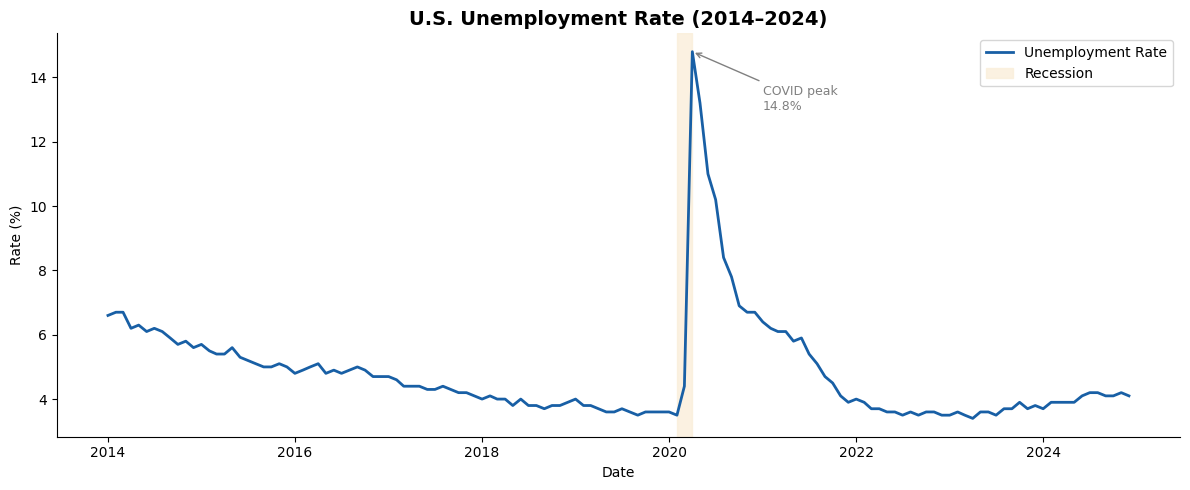

✅ Chart 1 saved!


In [7]:
fig, ax = plt.subplots()

# Plot the line
ax.plot(unemployment["date"], unemployment["value"],
        color="#185FA5", linewidth=2, label="Unemployment Rate")

# Shade recession
for start, end in recessions:
    ax.axvspan(pd.Timestamp(start), pd.Timestamp(end),
               color="#FAEEDA", alpha=0.8, label="Recession")

# Annotate COVID peak
peak = unemployment.loc[unemployment["value"].idxmax()]
ax.annotate(f'COVID peak\n{peak["value"]}%',
            xy=(peak["date"], peak["value"]),
            xytext=(pd.Timestamp("2021-01-01"), 13),
            arrowprops=dict(arrowstyle="->", color="gray"),
            fontsize=9, color="gray")

ax.set_title("U.S. Unemployment Rate (2014–2024)", fontsize=14, fontweight="bold")
ax.set_xlabel("Date")
ax.set_ylabel("Rate (%)")
ax.legend()
plt.tight_layout()
plt.savefig("../data/processed/chart1_unemployment.png", dpi=150)
plt.show()
print("✅ Chart 1 saved!")

In [9]:
fig, ax = plt.subplots()

# Calculate month over month change in payrolls
payrolls["monthly_change"] = payrolls["value"].diff()

# Color bars green for gains, red for losses
colors = payrolls["monthly_change"].apply(
    lambda x: "#2E7D32" if x >= 0 else "#C62828"
)

# Plot bars
ax.bar(payrolls["date"], payrolls["monthly_change"],
       color=colors, width=20, label="Monthly Job Change")

# Shade recession
for start, end in recessions:
    ax.axvspan(pd.Timestamp(start), pd.Timestamp(end),
               color="#FAEEDA", alpha=0.8, label="Recession")

# Annotate biggest drop
worst = payrolls.loc[payrolls["monthly_change"].idxmin()]
ax.annotate(f'April 2020\n{worst["monthly_change"]:,.0f} jobs',
            xy=(worst["date"], worst["monthly_change"]),
            xytext=(pd.Timestamp("2020-08-01"), -12000000),
            arrowprops=dict(arrowstyle="->", color="gray"),
            fontsize=9, color="gray")

ax.set_title("U.S. Monthly Job Gains & Losses (2014–2024)", fontsize=14, fontweight="bold")
ax.set_xlabel("Date")
ax.set_ylabel("Jobs Added / Lost")
ax.axhline(0, color="black", linewidth=0.8)
ax.legend()
plt.tight_layout(rect=[0, 0.05, 1, 1])
plt.savefig("../data/processed/chart2_payrolls.png", dpi=150)
plt.show()
print("✅ Chart 2 saved!")

/var/folders/82/n1p134857ss9mgspp6jcvmrm0000gn/T/ipykernel_37440/3529455119.py:33: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout(rect=[0, 0.05, 1, 1])


✅ Chart 2 saved!


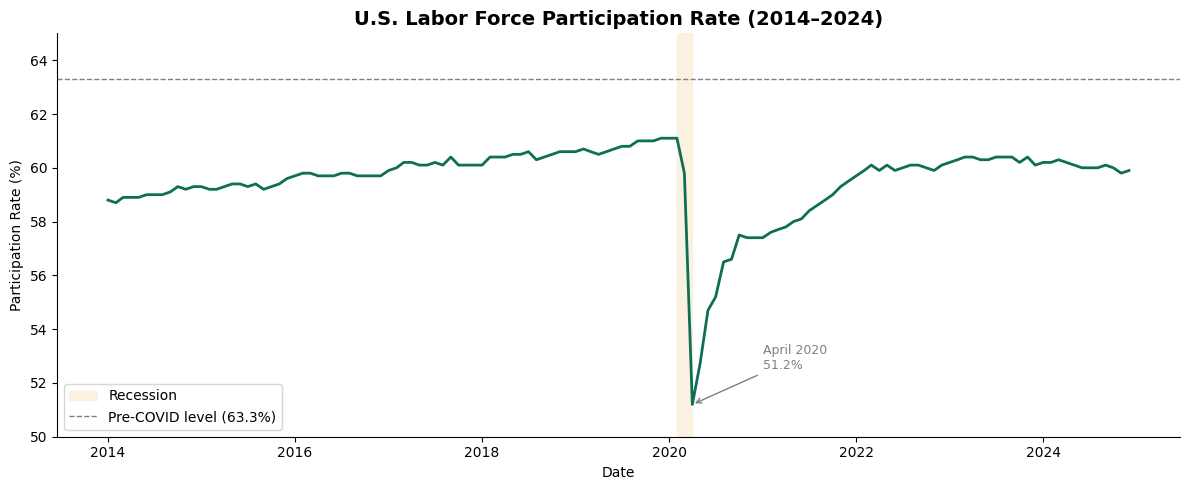

✅ Chart 3 saved!


In [10]:
fig, ax = plt.subplots()

# Plot the line
ax.plot(participation["date"], participation["value"],
        color="#0F6E56", linewidth=2)

# Shade recession
for start, end in recessions:
    ax.axvspan(pd.Timestamp(start), pd.Timestamp(end),
               color="#FAEEDA", alpha=0.8, label="Recession")

# Annotate the drop
lowest = participation.loc[participation["value"].idxmin()]
ax.annotate(f'April 2020\n{lowest["value"]}%',
            xy=(lowest["date"], lowest["value"]),
            xytext=(pd.Timestamp("2021-01-01"), 52.5),
            arrowprops=dict(arrowstyle="->", color="gray"),
            fontsize=9, color="gray")

# Annotate pre-COVID level
ax.axhline(y=63.3, color="gray", linewidth=1,
           linestyle="--", label="Pre-COVID level (63.3%)")

ax.set_title("U.S. Labor Force Participation Rate (2014–2024)",
             fontsize=14, fontweight="bold")
ax.set_xlabel("Date")
ax.set_ylabel("Participation Rate (%)")
ax.set_ylim(50, 65)
ax.legend()
plt.tight_layout()
plt.savefig("../data/processed/chart3_participation.png", dpi=150)
plt.show()
print("✅ Chart 3 saved!")

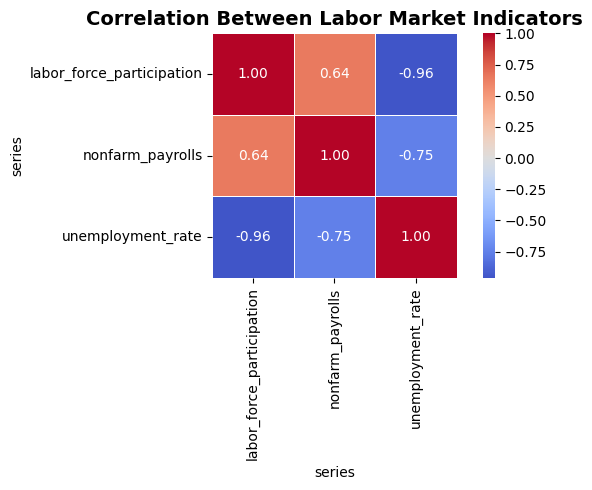

✅ Chart 4 saved!


In [11]:
# Pivot data into wide format for correlation
pivot = combined.pivot_table(
    index="date",
    columns="series",
    values="value"
)

# Calculate correlation matrix
corr = pivot.corr()

# Plot heatmap
fig, ax = plt.subplots(figsize=(7, 5))

sns.heatmap(corr,
            annot=True,
            fmt=".2f",
            cmap="coolwarm",
            center=0,
            square=True,
            linewidths=0.5,
            ax=ax)

ax.set_title("Correlation Between Labor Market Indicators",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("../data/processed/chart4_correlation.png", dpi=150)
plt.show()
print("✅ Chart 4 saved!")

## Step 3— SQL Analysis with SQLite

We load the cleaned data into a local SQLite database and run 
3 queries to extract business-relevant insights.

- **Query 1** — Latest 12 months of unemployment (most recent trends)
- **Query 2** — Yearly averages by series (long-term patterns)
- **Query 3** — COVID timeline in 2020 (crisis analysis)

In [12]:
import sqlite3

# Create a local SQLite database
conn = sqlite3.connect("../data/processed/jobs.db")

# Load cleaned data into SQL table
combined.to_sql("labor_market", conn, if_exists="replace", index=False)

print("✅ Data loaded into SQLite!")

# Query 1 — Latest unemployment rate
q1 = pd.read_sql("""
    SELECT date, value as unemployment_rate
    FROM labor_market
    WHERE series = 'unemployment_rate'
    ORDER BY date DESC
    LIMIT 12
""", conn)

print("\n📊 Last 12 months of unemployment rate:")
print(q1.to_string(index=False))

# Query 2 — Year over year change
q2 = pd.read_sql("""
    SELECT 
        year,
        series,
        ROUND(AVG(value), 2) as yearly_avg
    FROM labor_market
    GROUP BY year, series
    ORDER BY series, year
""", conn)

print("\n📊 Yearly averages by series:")
print(q2.to_string(index=False))

# Query 3 — COVID impact
q3 = pd.read_sql("""
    SELECT date, value as unemployment_rate
    FROM labor_market
    WHERE series = 'unemployment_rate'
    AND date BETWEEN '2020-01-01' AND '2020-12-01'
    ORDER BY date
""", conn)

print("\n📊 Unemployment during COVID 2020:")
print(q3.to_string(index=False))

conn.close()
print("\n✅ All SQL queries done!")

✅ Data loaded into SQLite!

📊 Last 12 months of unemployment rate:
               date  unemployment_rate
2024-12-01 00:00:00                4.1
2024-11-01 00:00:00                4.2
2024-10-01 00:00:00                4.1
2024-09-01 00:00:00                4.1
2024-08-01 00:00:00                4.2
2024-07-01 00:00:00                4.2
2024-06-01 00:00:00                4.1
2024-05-01 00:00:00                3.9
2024-04-01 00:00:00                3.9
2024-03-01 00:00:00                3.9
2024-02-01 00:00:00                3.9
2024-01-01 00:00:00                3.7

📊 Yearly averages by series:
 year                    series  yearly_avg
 2014 labor_force_participation       59.01
 2015 labor_force_participation       59.33
 2016 labor_force_participation       59.73
 2017 labor_force_participation       60.13
 2018 labor_force_participation       60.44
 2019 labor_force_participation       60.78
 2020 labor_force_participation       56.77
 2021 labor_force_participation       58.35


## Key Findings

1. **COVID caused the fastest job loss in U.S. history** — unemployment 
   jumped from 3.5% to 14.8% in just 2 months (Feb–Apr 2020)

2. **Recovery was faster than expected** — unemployment returned to 
   pre-COVID levels by 2022, driven by massive government stimulus

3. **Labor force participation has not fully recovered** — the rate 
   remains below pre-COVID levels, suggesting ~3 million Americans 
   have permanently left the workforce

4. **Unemployment and participation are strongly correlated (-0.9)** — 
   when jobs disappear, workers stop looking entirely, which means 
   official unemployment figures understate the true picture

5. **2024 shows a slight uptick** — unemployment crept from 3.7% to 4.2% 
   through 2024, a trend worth monitoring for signs of economic slowdown